In [3]:
#Bibliotecas
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

#Função para a apresentação da imagem
def apresentaImg(imagem):
    img = plt.figure(figsize = (30,28))
    ax = img.add_subplot(111)
    ax.imshow(imagem, cmap = 'gray')

#Carregando as imagens
vinho = cv2.imread('vinho.jpg')
vinho = cv2.cvtColor(vinho, cv2.COLOR_BGR2GRAY)

pratileira_vinhos = cv2.imread('pratileira_vinho.jpg')
pratileira_vinhos = cv2.cvtColor(pratileira_vinhos, cv2.COLOR_BGR2GRAY)

In [5]:
sift = cv2.xfeatures2d.SIFT_create()

In [9]:
kp1, des1 = sift.detectAndCompute(vinho, None)
kp2, des2 = sift.detectAndCompute(pratileira_vinhos, None)

In [10]:
forcaBruta = cv2.BFMatcher()

In [11]:
matches = forcaBruta.knnMatch(des1, des2, k = 2)


In [13]:
good = []

for match1, match2 in matches:
    if match1.distance < 0.6*match2.distance:
        good.append([match1]) 

In [15]:
sift_matches = cv2.drawMatchesKnn(vinho, kp1, pratileira_vinhos, kp2, good, None, flags = 2)

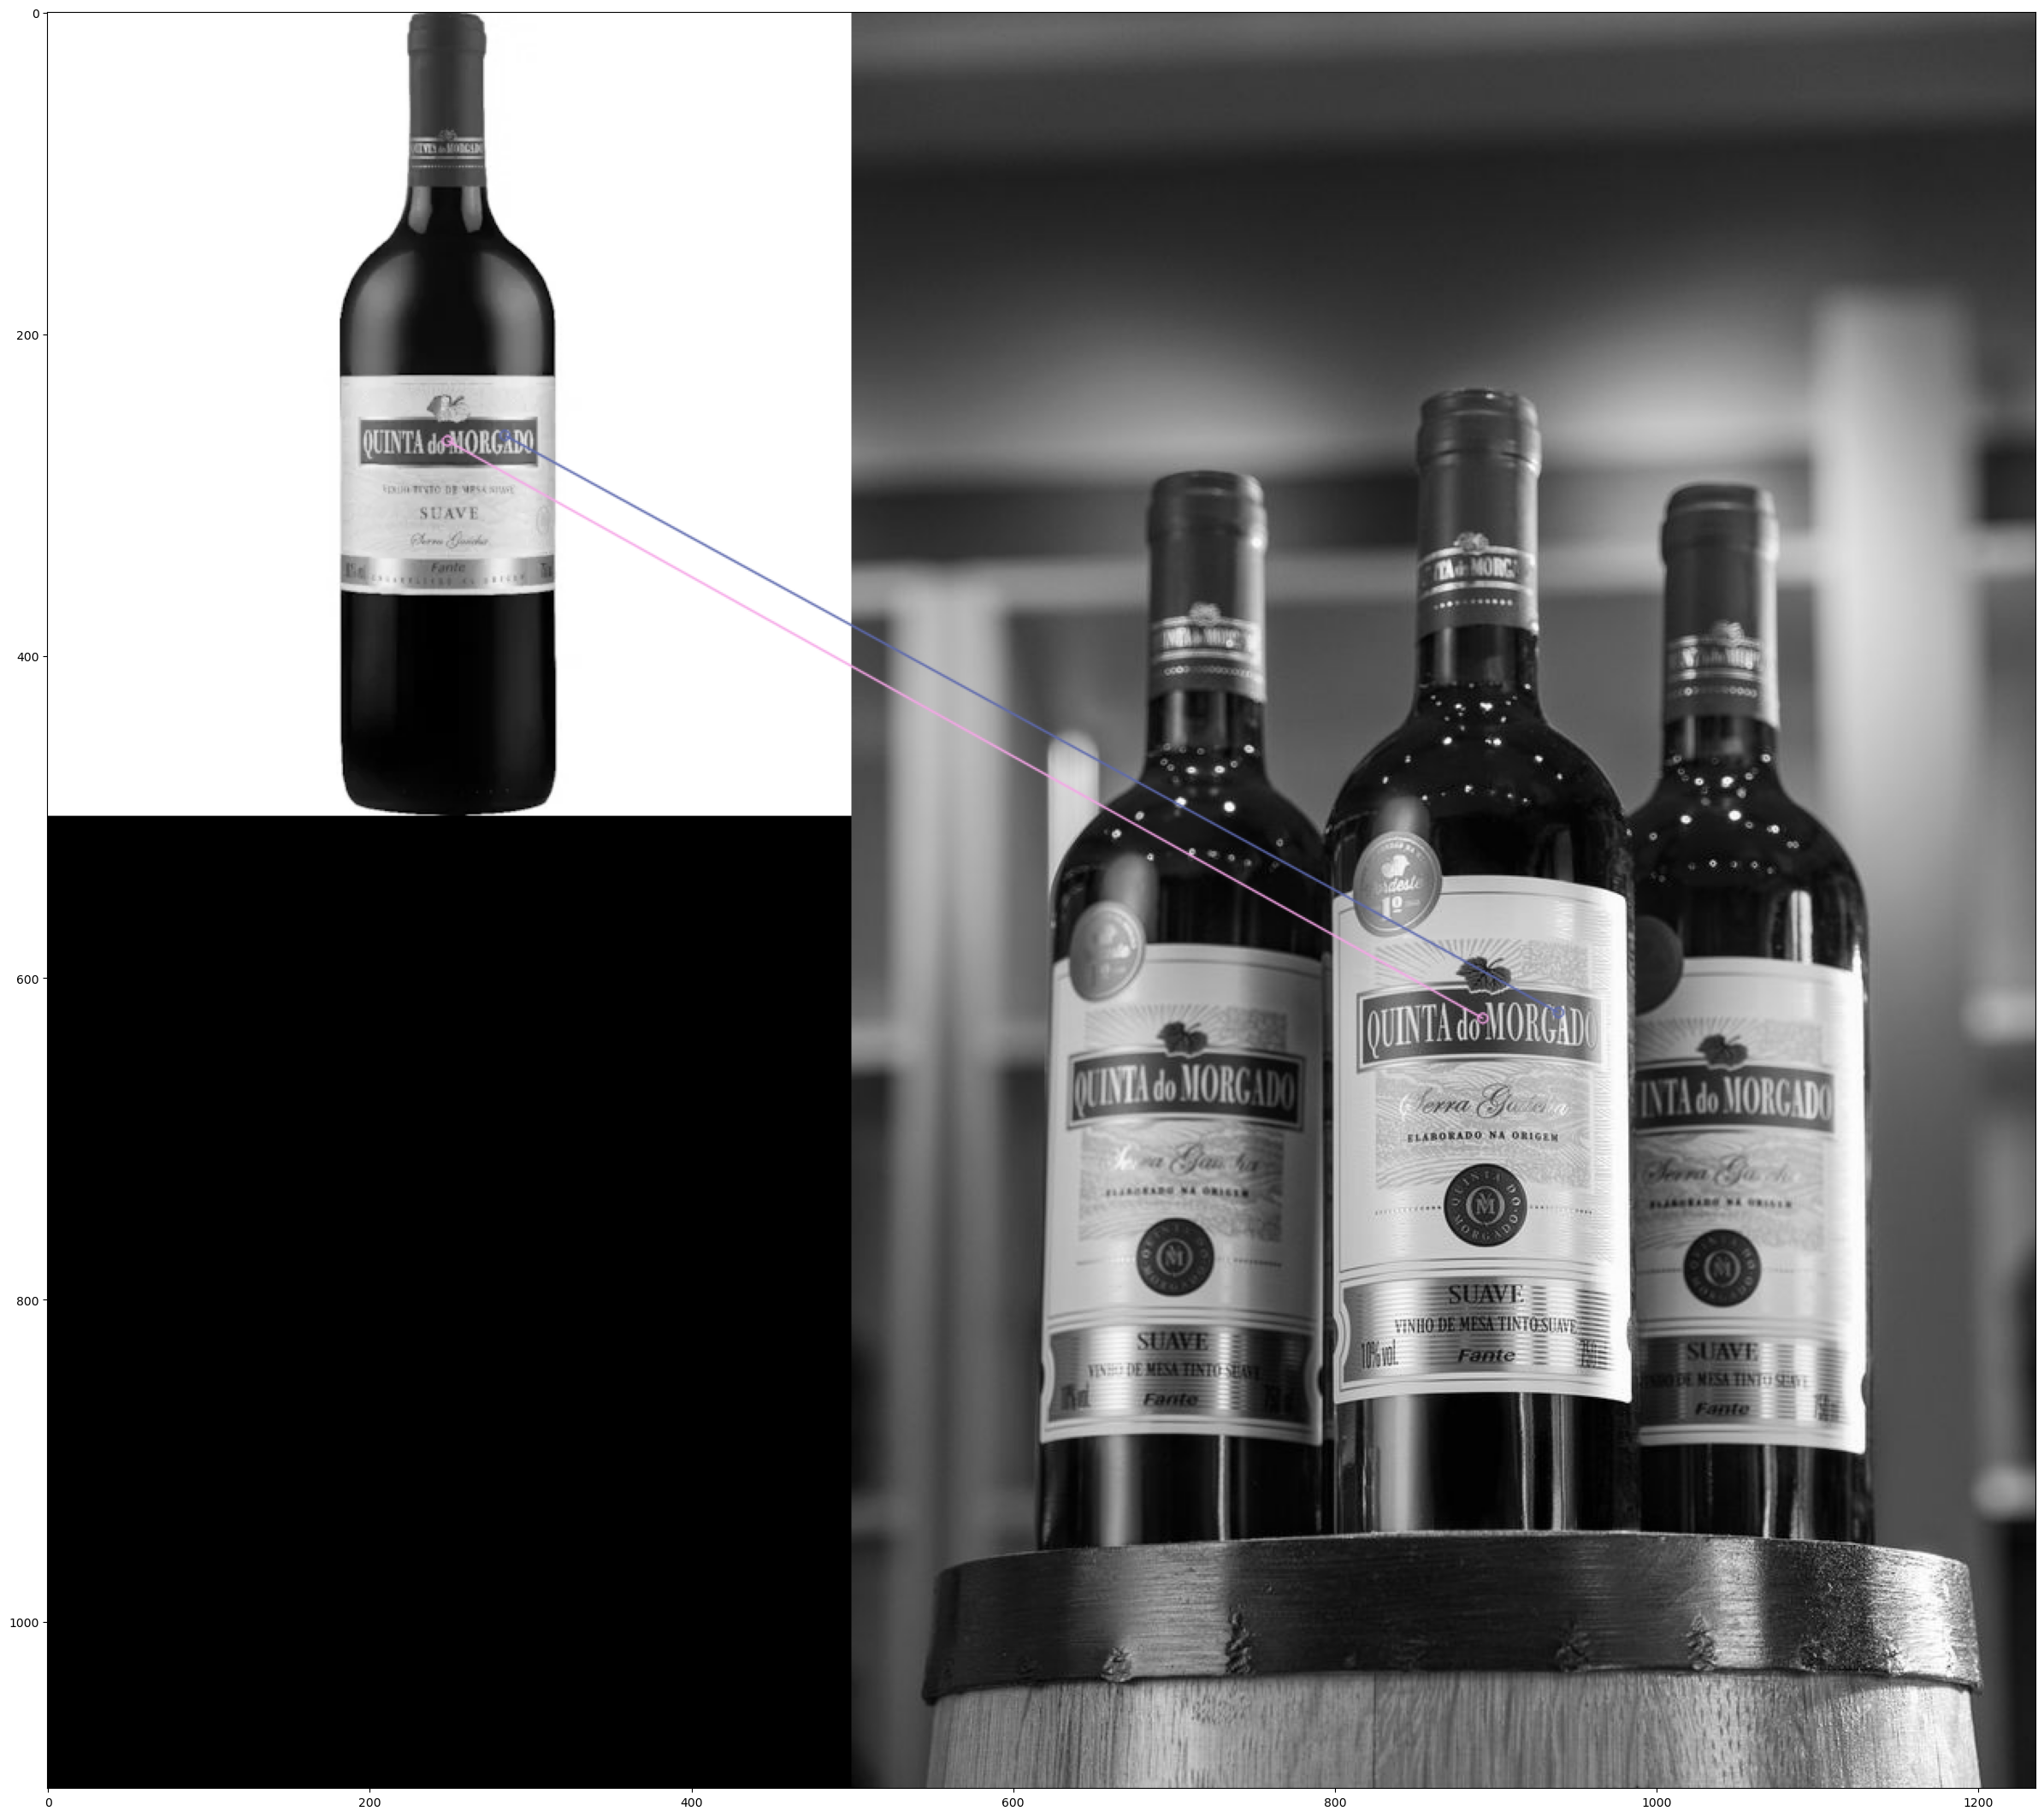

In [16]:
apresentaImg(sift_matches)